# LAB-02: Data Preprocessing and Visualization

**Aim**: Performing data cleaning, preprocessing, and visualization to prepare datasets for machine learning tasks.

## Data Preparation (Injecting Noise)
Since the Iris dataset is pristine, we will introduce some random missing values and type inconsistencies to demonstrate the cleaning operations effectively.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

if not os.path.exists('outputs'):
    os.makedirs('outputs')

# Load pristine dataset
df = pd.read_csv("../Iris.csv")

# Inject noise
np.random.seed(42)
df.loc[np.random.choice(df.index, 10, replace=False), 'SepalLengthCm'] = np.nan
df.loc[np.random.choice(df.index, 5, replace=False), 'Species'] = np.nan
df.loc[0, 'SepalWidthCm'] = 99.9  # Outlier/inconsistent value

# Copy for demonstrating row removal later
df_uncleaned = df.copy()

print("Noise Injected.")

Noise Injected.


## Experiment-1: Identify Missing Values
Write a Python program to Load a dataset using Pandas Identify missing values using isnull() and notnull(). Display the total count of missing values in each column.

In [2]:
# Identifying missing values
print("Total missing values per column:")
display(df.isnull().sum())

print("\nTotal valid (not null) values per column:")
display(df.notnull().sum())

Total missing values per column:


Id                0
SepalLengthCm    10
SepalWidthCm      0
PetalLengthCm     0
PetalWidthCm      0
Species           5
dtype: int64


Total valid (not null) values per column:


Id               150
SepalLengthCm    140
SepalWidthCm     150
PetalLengthCm    150
PetalWidthCm     150
Species          145
dtype: int64

## Experiment-2: Remove rows containing missing values
Write a program to Read a CSV dataset Remove rows containing missing values. Compare the dataset size before and after cleaning.

In [3]:
# Dataset size before
print("Size before dropping NaNs:", df_uncleaned.shape)

# Drop missing values
df_dropped = df_uncleaned.dropna()

# Dataset size after
print("Size after dropping NaNs:", df_dropped.shape)

Size before dropping NaNs: (150, 6)
Size after dropping NaNs: (135, 6)


## Experiment-3: Replace missing values
Write a Python program to load a dataset with missing values Replace missing numerical values using fillna() with mean or median. Replace missing categorical values using appropriate constants.

In [4]:
# Replace numerical with Mean
mean_val = df['SepalLengthCm'].mean()
df['SepalLengthCm'].fillna(mean_val, inplace=True)

# Replace categorical with constant mode or label
df['Species'].fillna('Unknown_Species', inplace=True)

print("Remaining missing values:\n", df.isnull().sum())

Remaining missing values:
 Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


/var/folders/lf/qc_zbjws63q9y9z07849hwwc0000gn/T/ipykernel_6207/2193852090.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SepalLengthCm'].fillna(mean_val, inplace=True)
/var/folders/lf/qc_zbjws63q9y9z07849hwwc0000gn/T/ipykernel_6207/2193852090.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

## Experiment-4: Convert Data Types
Write a program to load a dataset, Display column data types, Convert selected columns to appropriate data types using astype(). Verify the changes.

In [5]:
print("Original data types:\n", df.dtypes)

# Convert Species to category and Id to int32
df['Species'] = df['Species'].astype('category')
df['Id'] = df['Id'].astype('int32')

print("\nModified data types:\n", df.dtypes)

Original data types:
 Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Modified data types:
 Id                  int32
SepalLengthCm     float64
SepalWidthCm      float64
PetalLengthCm     float64
PetalWidthCm      float64
Species          category
dtype: object


## Experiment-5: Rename columns
Write a Python program to load a dataset, rename column names using rename() for better readability. Display the updated DataFrame.

In [6]:
# Rename columns
df_renamed = df.rename(columns={
    'SepalLengthCm': 'sepal_length',
    'SepalWidthCm': 'sepal_width',
    'PetalLengthCm': 'petal_length',
    'PetalWidthCm': 'petal_width',
    'Species': 'class_label'
})

display(df_renamed.head())

,Id,sepal_length,sepal_width,petal_length,petal_width,class_label
0,1,5.1,99.9,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Experiment-6: Incorrect Values
Write a program to identify inconsistent or incorrect values in a dataset. Replace them using the replace() function. Verify the corrected data.

In [7]:
# We injected 99.9 as an outlier at index 0 for sepal_width earlier.
print("Before replacing anomaly:", df_renamed['sepal_width'].iloc[0])

# Replace 99.9 with the median
median_width = df_renamed['sepal_width'].median()
df_renamed['sepal_width'] = df_renamed['sepal_width'].replace(99.9, median_width)

print("After replacing anomaly:", df_renamed['sepal_width'].iloc[0])

Before replacing anomaly: 99.9
After replacing anomaly: 3.0


## Experiment-7: Line plot and Bar plot
Write a Python program to load a dataset. Create a line plot to show trends over time. Create a bar plot to compare categorical data.

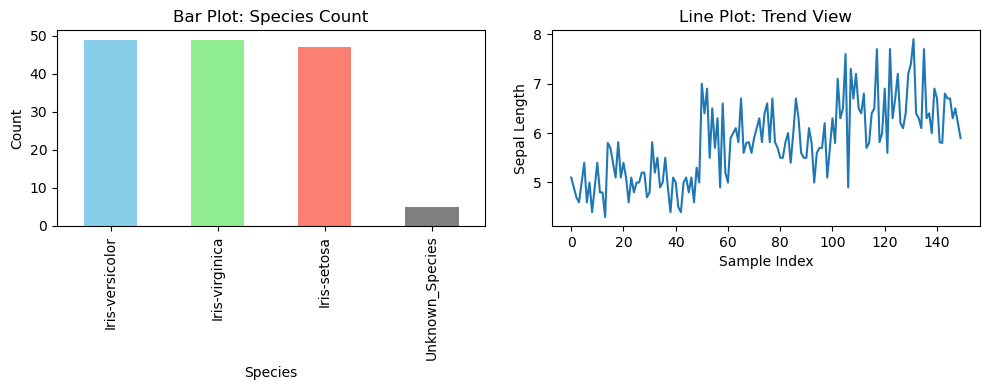

In [8]:
# Bar plot for class label counts
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df_renamed['class_label'].value_counts().plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon', 'gray'])
plt.title("Bar Plot: Species Count")
plt.xlabel("Species")
plt.ylabel("Count")

# Line plot (plotting features over index simulating time)
plt.subplot(1, 2, 2)
plt.plot(df_renamed.index, df_renamed['sepal_length'], label='Sepal Length')
plt.title("Line Plot: Trend View")
plt.xlabel("Sample Index")
plt.ylabel("Sepal Length")

plt.tight_layout()
plt.savefig('outputs/bar_line_plots.png')
plt.show()

## Experiment-8: Scatter plot
Write a program to load a dataset. Create a scatter plot between two numerical features. Interpret the relationship.

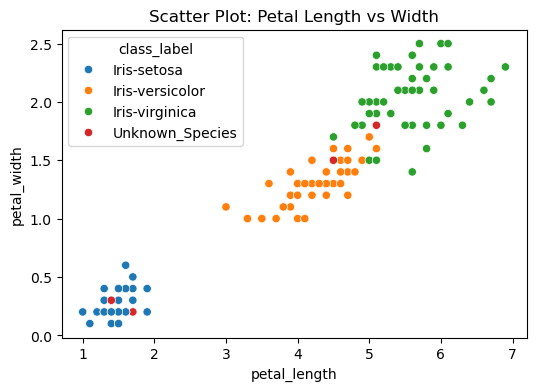

Interpretation: There is a strong, positive linear correlation between petal length and petal width. Also, the species are well-separated based on these two variables.


In [9]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_renamed, x='petal_length', y='petal_width', hue='class_label')
plt.title("Scatter Plot: Petal Length vs Width")
plt.savefig('outputs/scatter_plot.png')
plt.show()

print("Interpretation: There is a strong, positive linear correlation between petal length and petal width. Also, the species are well-separated based on these two variables.")

## Experiment-9: Histogram
Write a Python program to load a dataset. Plot a histogram for a selected numerical feature. Analyse data distribution and skewness.

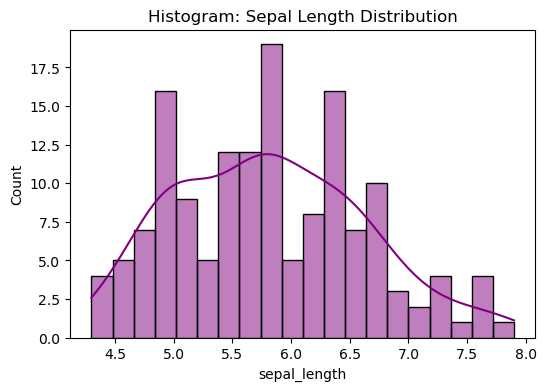

Interpretation: The distribution is somewhat uniform/multimodal rather than purely normal. There is slight right-skewness.


In [10]:
plt.figure(figsize=(6, 4))
sns.histplot(df_renamed['sepal_length'], kde=True, bins=20, color='purple')
plt.title("Histogram: Sepal Length Distribution")
plt.savefig('outputs/histogram.png')
plt.show()

print("Interpretation: The distribution is somewhat uniform/multimodal rather than purely normal. There is slight right-skewness.")

## Experiment-10: Boxplot
Write a program to load a dataset. Create a boxplot for numerical attributes. Identify and interpret potential outliers.

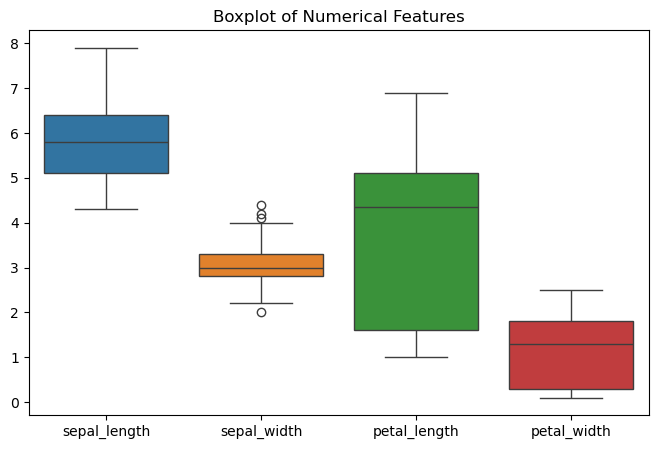

Interpretation: The boxplot shows the interquartile range (IQR). Petal measurements have wide ranges and multiple modalities. 'sepal_width' shows some minor outliers (dots outside the whiskers).


In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_renamed[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])
plt.title("Boxplot of Numerical Features")
plt.savefig('outputs/boxplot.png')
plt.show()

print("Interpretation: The boxplot shows the interquartile range (IQR). Petal measurements have wide ranges and multiple modalities. 'sepal_width' shows some minor outliers (dots outside the whiskers).")